In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('penguins.csv')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [20]:
print(df.isnull().sum())
print(df.duplicated().sum())

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64
1


In [42]:
df['sex'].unique()

array([ 0.,  1., nan])

In [ ]:
df['sex'] = df['sex'].replace('.', np.nan)
df['sex'] = df['sex'].map({'MALE':0, 'FEMALE':1})
mod_sex = df['sex'].mode()[0]

df['sex'] = df['sex'].fillna(mod_sex)

## EA

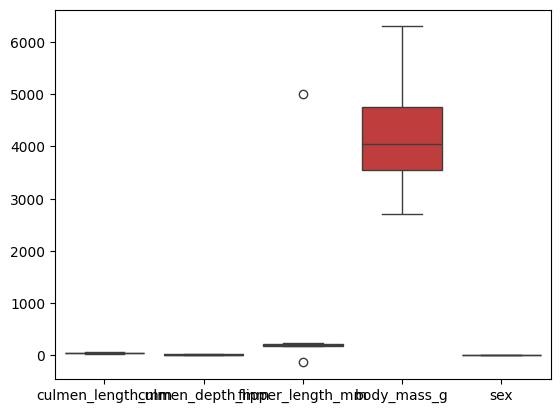

In [57]:
sns.boxplot(df)
plt.show()

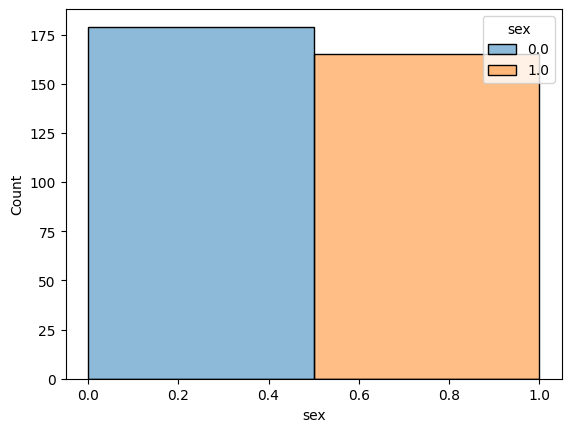

In [56]:
sns.histplot(data=df, x=df['sex'], hue=df['sex'], bins=2)
plt.show()

## Modedl

In [24]:
X = df.drop('sex', axis=1)
y = df['sex']

In [ ]:
def kmean(data, k=2, max_iterations=100):
    n_samples, n_features = df.shape
    random_idx = np.random.choice(n_samples, k, replace=False)
    centroids = df[random_idx]

    for i in range(max_iterations):
        clusters = [[] for _ in range(k)]
        cluster_labels = []

        for point in df:
            d = [np.sqrt(np.sum((point- c)**2)) for c in centroids]
            cluster_idx = np.argmin(d)
            clusters[cluster_idx].append(point)